# 04 — EDA Plots & Final Output

**Purpose:**
1. Plot RT distributions per player (histogram + KDE) for easy vs hard
2. Plot offensive shot rate per player (bar chart)
3. Plot shot type frequency heatmap (18 types × men/women)
4. Plot court-center distance distribution with easy/hard split
5. Check for class imbalance (offensive vs defensive)
6. Export `dataset.csv` with final modelling columns
7. Save all figures to `EDA/figs/`

**Input:** `EDA/data/shuttleset_features.parquet`

**Outputs:**
- `EDA/data/dataset.csv`
- `EDA/figs/*.png`

## Imports and setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

OUTPUT_DIR = Path("data")
FIGS_DIR = Path("figs")
FIGS_DIR.mkdir(exist_ok=True)

# Global plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
EASY_COLOR = "#4C72B0"
HARD_COLOR = "#DD8452"

input_path = OUTPUT_DIR / "shuttleset_final_features.parquet"
assert input_path.exists(), (
    f"Input not found: {input_path}\n"
    "Run step03_feature_engineering.ipynb first."
)

df = pd.read_parquet(input_path)
print(f"Loaded: {len(df):,} strokes, {df['player_name'].nunique()} players")

Loaded: 25,695 strokes, 22 players


## Player gender mapping

In [3]:
from config import PLAYER_GENDER

df["gender"] = df["player_name"].map(PLAYER_GENDER)

unmapped = df[df["gender"].isna()]["player_name"].unique()
if len(unmapped) > 0:
    print(f"Players missing from PLAYER_GENDER: {unmapped}")
else:
    print("All players have a gender mapping")

All players have a gender mapping


## Helper: save figure

In [4]:
def save_fig(filename: str) -> None:
    """Save the current figure to EDA/figs/ as a PNG."""
    path = FIGS_DIR / filename
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")

## Plot 1 — RT distributions per player (histogram + KDE), easy vs hard

Saved: figs/rt_distributions_per_player.png


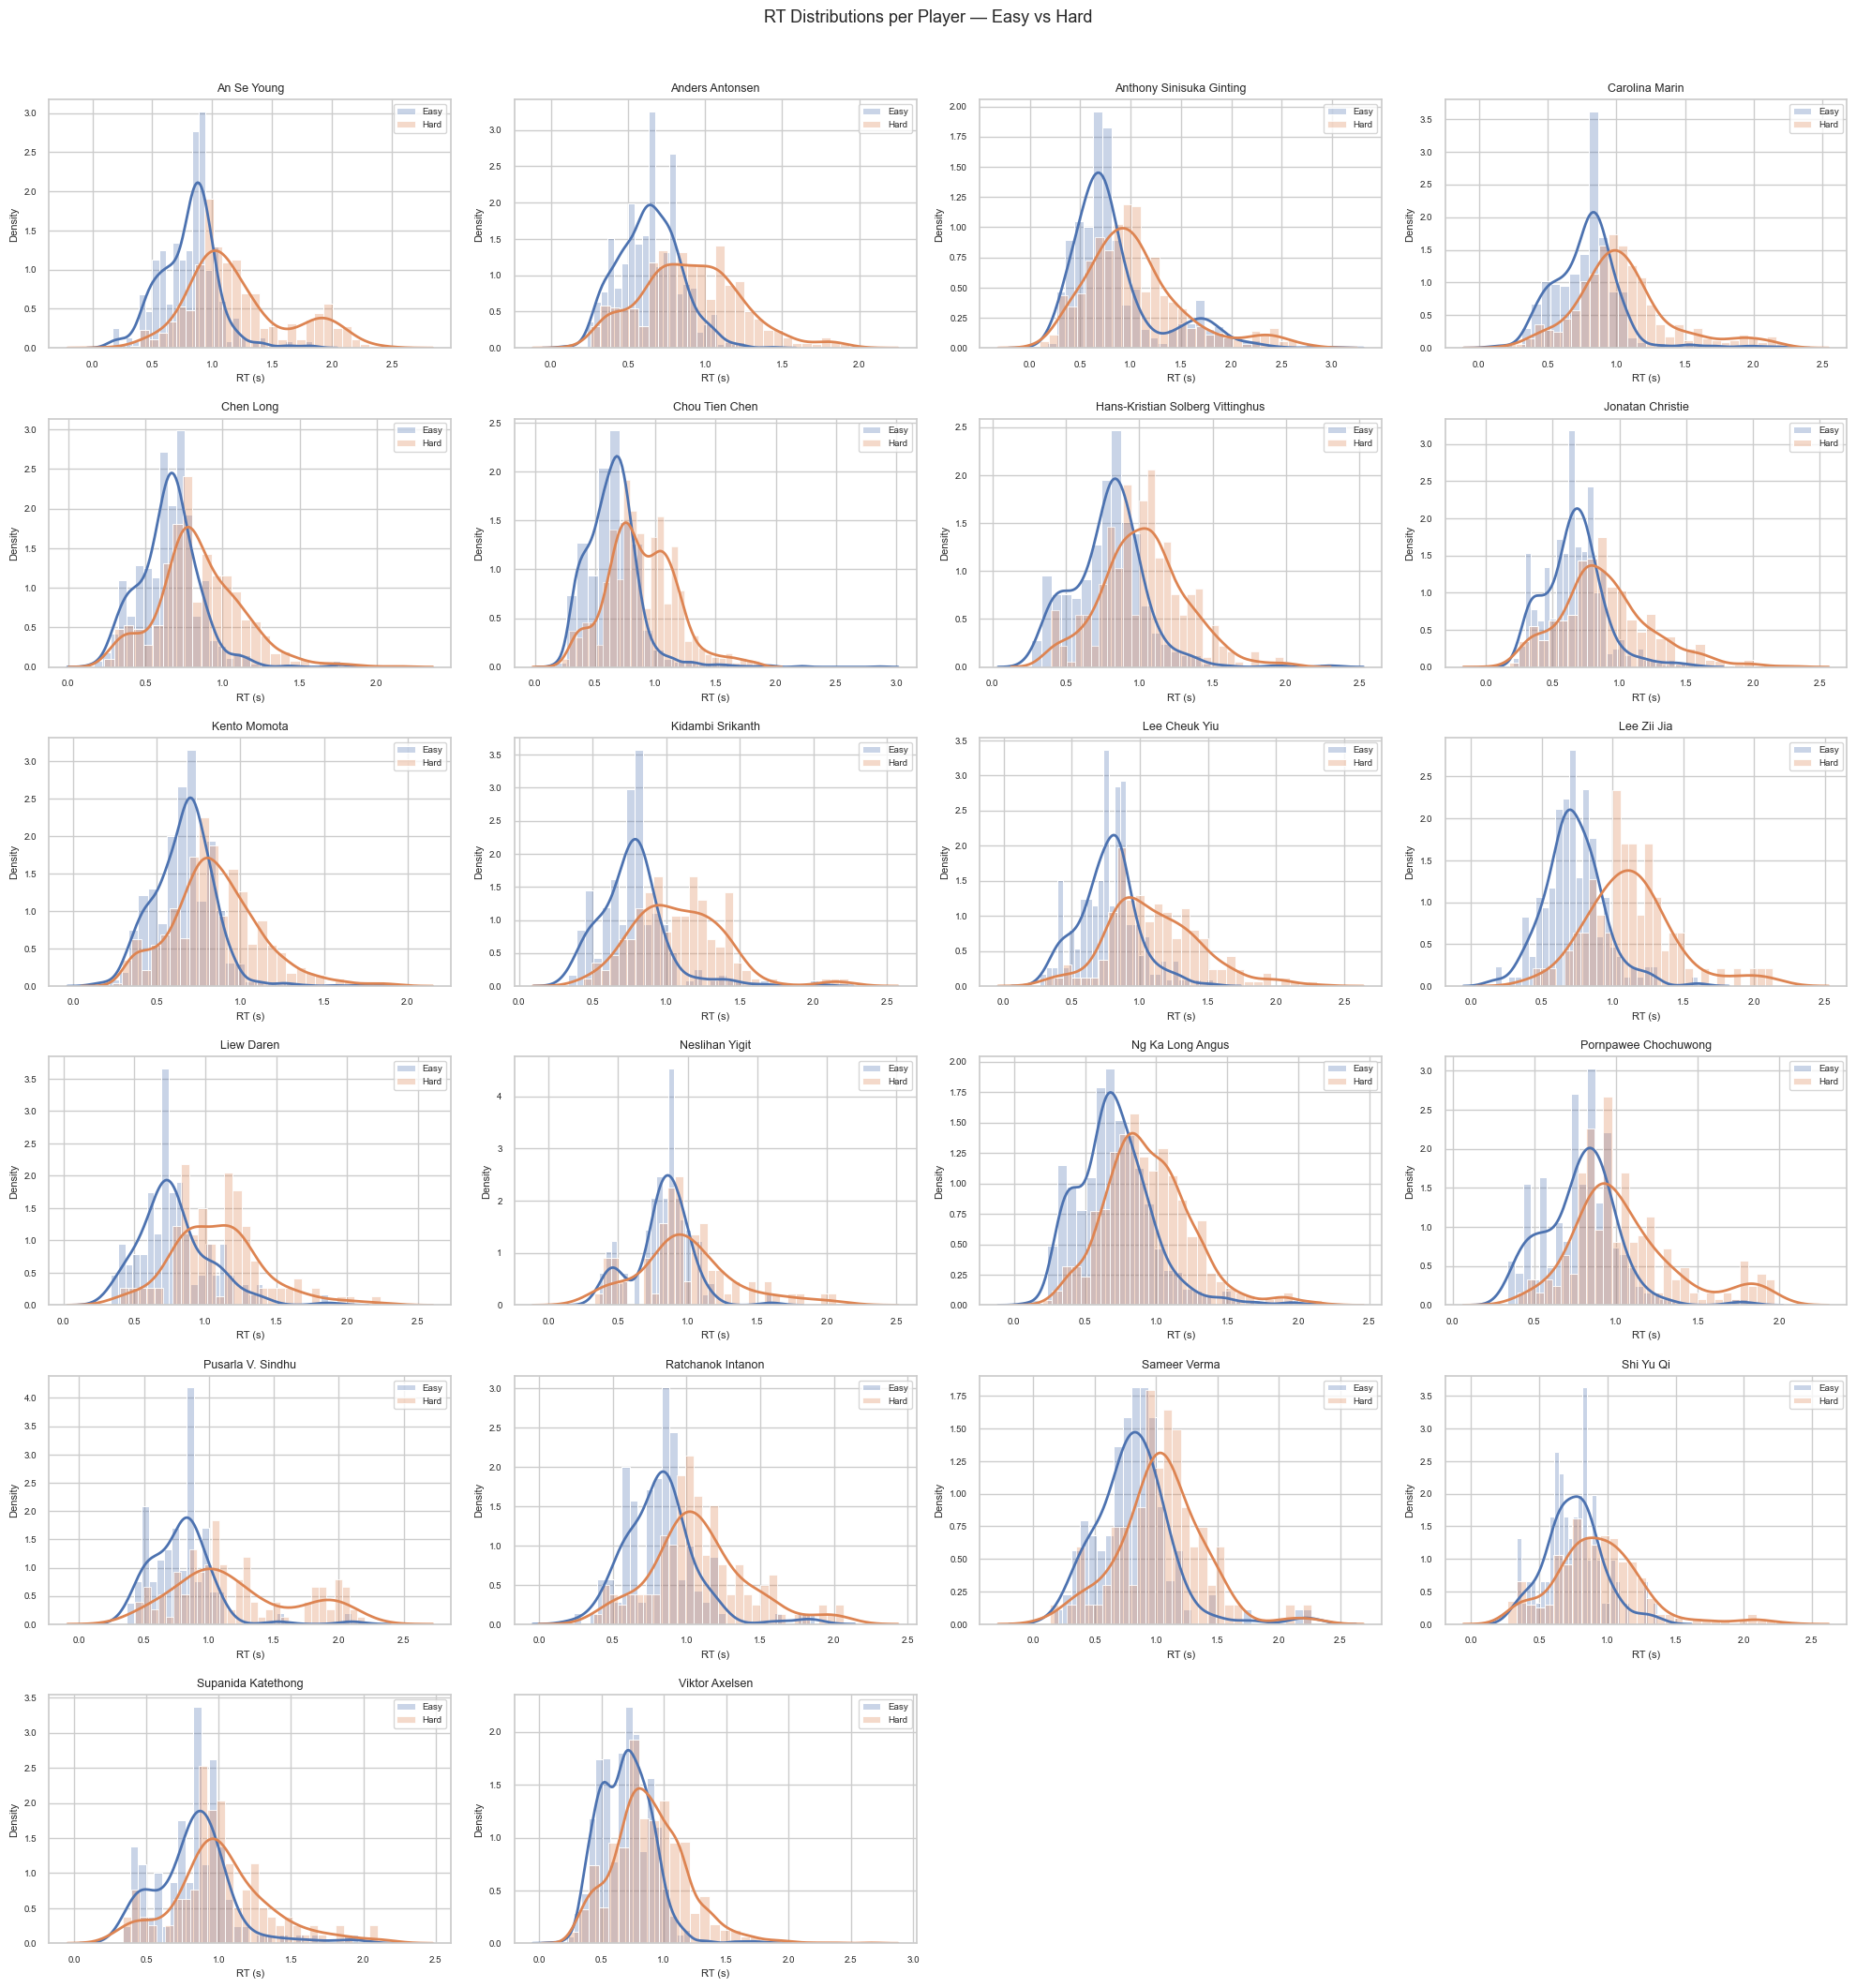

In [4]:
def plot_rt_distributions(data: pd.DataFrame) -> None:
    """
    For each player, plot overlapping RT histograms + KDE curves
    for easy (is_hard=0) and hard (is_hard=1) conditions.
    One subplot per player, arranged in a grid.
    """
    # Only strokes with a valid RT and a difficulty label
    plot_df = data.dropna(subset=["reaction_time_s", "is_hard"]).copy()

    players = sorted(plot_df["player_name"].unique())
    n_players = len(players)
    n_cols = 4
    n_rows = int(np.ceil(n_players / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 5, n_rows * 3.5),
        sharey=False,
    )
    axes_flat = axes.flatten()

    for i, player in enumerate(players):
        ax = axes_flat[i]
        player_df = plot_df[plot_df["player_name"] == player]

        for label, color, name in [
            (0, EASY_COLOR, "Easy"),
            (1, HARD_COLOR, "Hard"),
        ]:
            subset = player_df[player_df["is_hard"] == label]["reaction_time_s"]
            if len(subset) < 5:
                continue
            sns.histplot(
                subset,
                ax=ax,
                color=color,
                alpha=0.3,
                bins=30,
                stat="density",
                label=name,
            )
            sns.kdeplot(
                subset,
                ax=ax,
                color=color,
                linewidth=2,
            )

        ax.set_title(player, fontsize=9)
        ax.set_xlabel("RT (s)", fontsize=8)
        ax.set_ylabel("Density", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7)

    # Hide unused subplots
    for j in range(n_players, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(
        "RT Distributions per Player — Easy vs Hard",
        fontsize=13,
        y=1.01,
    )
    plt.tight_layout()
    save_fig("rt_distributions_per_player.png")
    plt.show()


plot_rt_distributions(df)

## Plot 2 — Offensive shot rate per player (bar chart)

Saved: figs/offensive_shot_rate_per_player.png


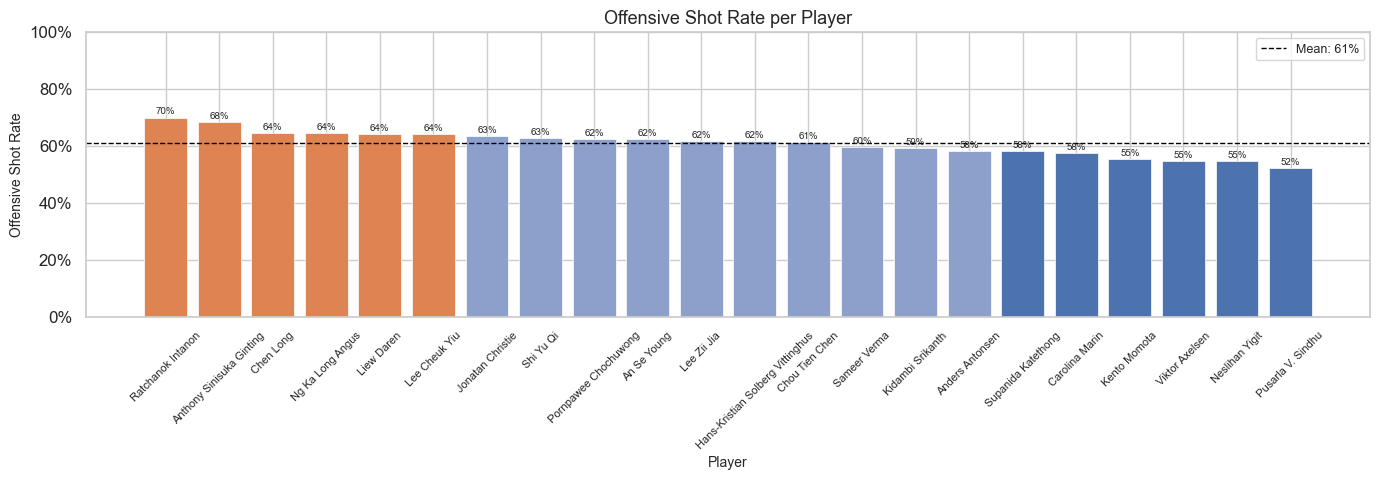


Most offensive players:
             player_name  offensive_rate
       Ratchanok Intanon        0.699620
Anthony Sinisuka Ginting        0.683913
               Chen Long        0.644590

Most defensive players:
      player_name  offensive_rate
   Viktor Axelsen        0.546672
   Neslihan Yigit        0.546448
Pusarla V. Sindhu        0.523364


In [5]:
def plot_offensive_rate(data: pd.DataFrame) -> None:
    """
    Bar chart of offensive shot rate (proportion of non-service strokes
    that are offensive) per player, sorted descending.
    Extreme players (top/bottom 3) are annotated.
    """
    # Exclude services (NaN is_offensive)
    plot_df = data.dropna(subset=["is_offensive"]).copy()

    rates = (
        plot_df.groupby("player_name")["is_offensive"]
        .mean()
        .reset_index()
        .rename(columns={"is_offensive": "offensive_rate"})
        .sort_values("offensive_rate", ascending=False)
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(14, 5))

    bar_colors = [
        HARD_COLOR if r > rates["offensive_rate"].quantile(0.75)
        else EASY_COLOR if r < rates["offensive_rate"].quantile(0.25)
        else "#8da0cb"
        for r in rates["offensive_rate"]
    ]

    bars = ax.bar(
        rates["player_name"],
        rates["offensive_rate"],
        color=bar_colors,
        edgecolor="white",
        linewidth=0.5,
    )

    # Annotate bars with percentage
    for bar, rate in zip(bars, rates["offensive_rate"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{rate:.0%}",
            ha="center",
            va="bottom",
            fontsize=7,
        )

    ax.axhline(
        rates["offensive_rate"].mean(),
        color="black",
        linestyle="--",
        linewidth=1,
        label=f"Mean: {rates['offensive_rate'].mean():.0%}",
    )

    ax.set_title("Offensive Shot Rate per Player", fontsize=13)
    ax.set_xlabel("Player", fontsize=10)
    ax.set_ylabel("Offensive Shot Rate", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.legend(fontsize=9)

    plt.tight_layout()
    save_fig("offensive_shot_rate_per_player.png")
    plt.show()

    print("\nMost offensive players:")
    print(rates.head(3).to_string(index=False))
    print("\nMost defensive players:")
    print(rates.tail(3).to_string(index=False))


plot_offensive_rate(df)

## Plot 3 — Shot type frequency heatmap overall

Saved: figs/shot_type_heatmap_overall.png


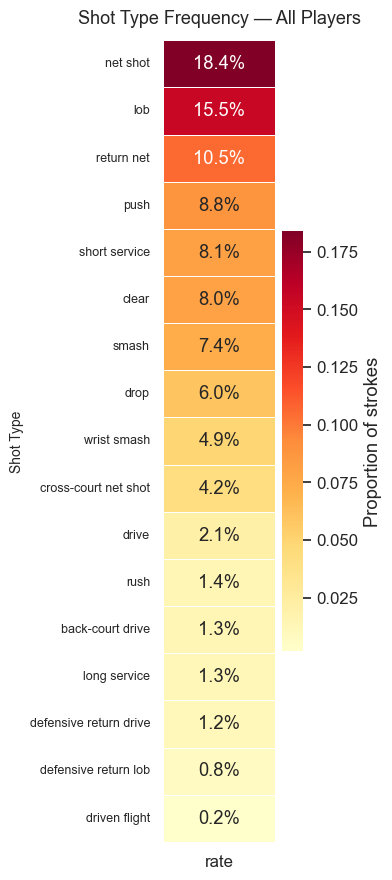

In [6]:
def plot_shot_type_heatmap_overall(data: pd.DataFrame) -> None:
    """
    Heatmap of shot type usage rates across all players combined,
    sorted by frequency.
    """
    plot_df = data.dropna(subset=["type_en"]).copy()

    counts = plot_df["type_en"].value_counts(normalize=True).reset_index()
    counts.columns = ["type_en", "rate"]
    counts = counts.sort_values("rate", ascending=False)

    heatmap_df = counts.set_index("type_en")[["rate"]]

    fig, ax = plt.subplots(figsize=(4, 9))
    sns.heatmap(
        heatmap_df,
        ax=ax,
        annot=True,
        fmt=".1%",
        cmap="YlOrRd",
        linewidths=0.4,
        cbar_kws={"label": "Proportion of strokes"},
    )
    ax.set_title("Shot Type Frequency — All Players", fontsize=13, pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("Shot Type", fontsize=10)
    ax.tick_params(axis="y", rotation=0, labelsize=9)

    plt.tight_layout()
    save_fig("shot_type_heatmap_overall.png")
    plt.show()

plot_shot_type_heatmap_overall(df)

## Plot 4 — Shot type frequency heatmap (18 types × men/women)

Saved: figs/shot_type_heatmap_by_gender.png


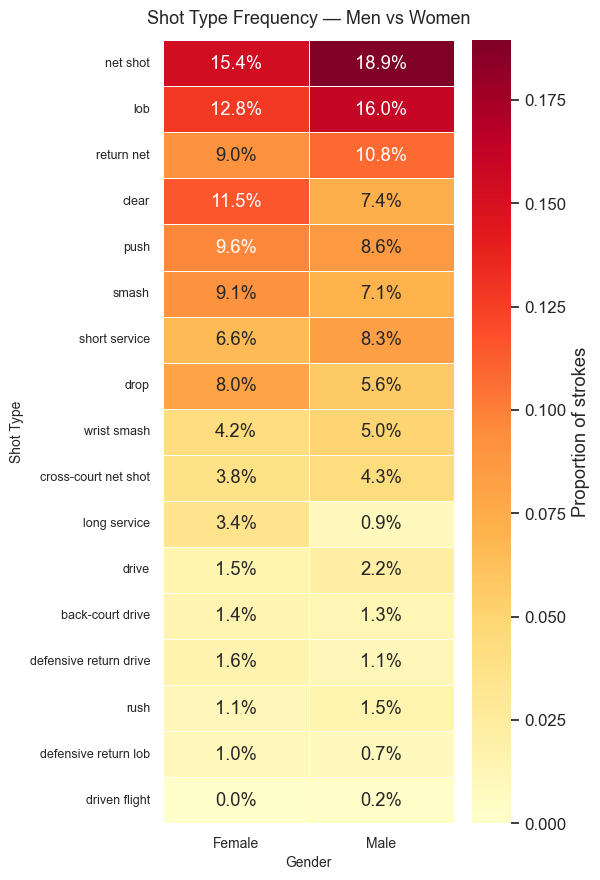

In [6]:
def plot_shot_type_heatmap(data: pd.DataFrame) -> None:
    """
    Heatmap of shot type usage rates — rows are the 18 shot types,
    columns are Men and Women. Values are proportion of each gender's
    strokes that are that shot type.
    """
    plot_df = data.dropna(subset=["gender", "type_en"]).copy()

    # Count shot type per gender, normalize within each gender
    counts = (
        plot_df.groupby(["gender", "type_en"])
        .size()
        .reset_index(name="count")
    )
    totals = plot_df.groupby("gender").size().reset_index(name="total")
    counts = counts.merge(totals, on="gender")
    counts["rate"] = counts["count"] / counts["total"]

    heatmap_df = counts.pivot(
        index="type_en", columns="gender", values="rate"
    ).fillna(0)

    heatmap_df["_total"] = heatmap_df.sum(axis=1)
    heatmap_df = heatmap_df.sort_values("_total", ascending=False).drop(
        columns="_total"
    )

    fig, ax = plt.subplots(figsize=(6, 9))

    sns.heatmap(
        heatmap_df,
        ax=ax,
        annot=True,
        fmt=".1%",
        cmap="YlOrRd",
        linewidths=0.4,
        cbar_kws={"label": "Proportion of strokes"},
    )

    ax.set_title(
        "Shot Type Frequency — Men vs Women",
        fontsize=13,
        pad=12,
    )
    ax.set_xlabel("Gender", fontsize=10)
    ax.set_ylabel("Shot Type", fontsize=10)
    ax.tick_params(axis="x", rotation=0, labelsize=10)
    ax.tick_params(axis="y", rotation=0, labelsize=9)

    plt.tight_layout()
    save_fig("shot_type_heatmap_by_gender.png")
    plt.show()


plot_shot_type_heatmap(df)

## Plot 5 — Court-center distance distribution with easy/hard split

Saved: figs/court_center_distance_distribution.png


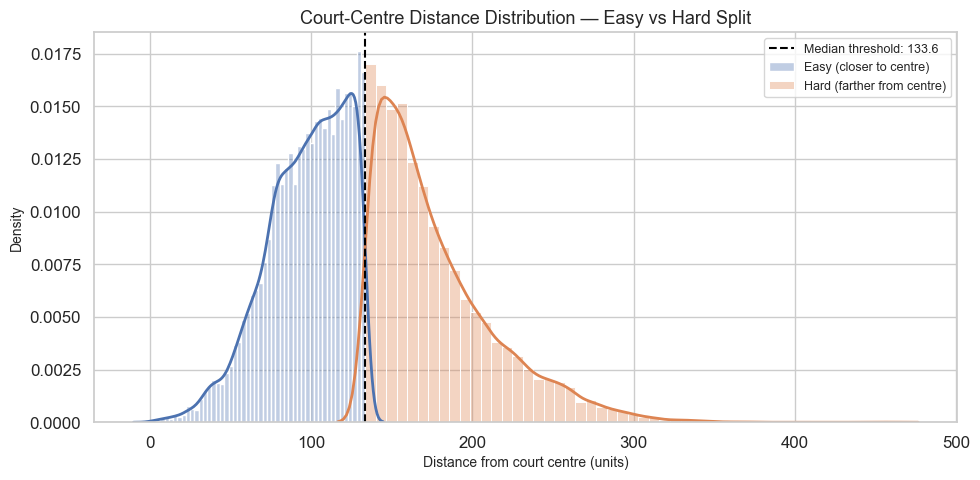

Median threshold: 133.5864
Easy strokes: 12,846
Hard strokes: 12,849


In [7]:
def plot_distance_distribution(data: pd.DataFrame) -> None:
    """
    Histogram + KDE of court-center distance for the full dataset.
    Median split threshold is marked with a vertical line.
    Easy and hard regions are shaded to confirm the split is intuitive.
    """
    plot_df = data.dropna(subset=["court_center_distance", "is_hard"]).copy()
    threshold = plot_df["court_center_distance"].median()

    fig, ax = plt.subplots(figsize=(10, 5))

    for label, color, name in [
        (0, EASY_COLOR, "Easy (closer to centre)"),
        (1, HARD_COLOR, "Hard (farther from centre)"),
    ]:
        subset = plot_df[plot_df["is_hard"] == label]["court_center_distance"]
        sns.histplot(
            subset,
            ax=ax,
            color=color,
            alpha=0.35,
            bins=50,
            stat="density",
            label=name,
        )
        sns.kdeplot(
            subset,
            ax=ax,
            color=color,
            linewidth=2,
        )

    ax.axvline(
        threshold,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"Median threshold: {threshold:.1f}",
    )

    ax.set_title(
        "Court-Centre Distance Distribution — Easy vs Hard Split",
        fontsize=13,
    )
    ax.set_xlabel("Distance from court centre (units)", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.legend(fontsize=9)

    plt.tight_layout()
    save_fig("court_center_distance_distribution.png")
    plt.show()

    print(f"Median threshold: {threshold:.4f}")
    print(f"Easy strokes: {(plot_df['is_hard'] == 0).sum():,}")
    print(f"Hard strokes: {(plot_df['is_hard'] == 1).sum():,}")


plot_distance_distribution(df)

## Plot 6 — Class imbalance: overall offensive vs defensive rate

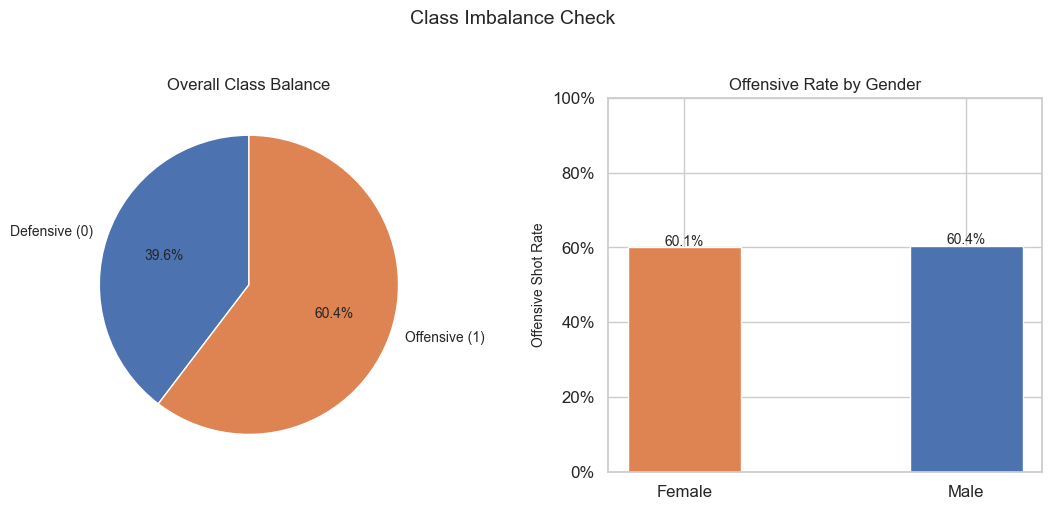

Stroke counts:
  Defensive (0): 8,840 (39.6%)
  Offensive (1): 13,459 (60.4%)

Imbalance ratio: 1.52:1


In [8]:
def plot_class_imbalance(data: pd.DataFrame) -> None:
    """
    Pie chart + printed counts showing the overall split between
    offensive (1) and defensive (0) strokes, excluding services (NaN).
    """
    plot_df = data.dropna(subset=["is_offensive"]).copy()

    counts = plot_df["is_offensive"].value_counts().sort_index()
    labels = ["Defensive (0)", "Offensive (1)"]
    colors = [EASY_COLOR, HARD_COLOR]

    fig, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(11, 5))

    ax_pie.pie(
        counts,
        labels=labels,
        colors=colors,
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 10},
    )
    ax_pie.set_title("Overall Class Balance", fontsize=12)

    gender_rates = (
        plot_df.groupby("gender")["is_offensive"]
        .mean()
        .reset_index()
        .rename(columns={"is_offensive": "offensive_rate"})
    )
    ax_bar.bar(
        gender_rates["gender"],
        gender_rates["offensive_rate"],
        color=[HARD_COLOR, EASY_COLOR],
        edgecolor="white",
        width=0.4,
    )
    for i, row in gender_rates.iterrows():
        ax_bar.text(
            i,
            row["offensive_rate"] + 0.005,
            f"{row['offensive_rate']:.1%}",
            ha="center",
            fontsize=10,
        )
    ax_bar.set_title("Offensive Rate by Gender", fontsize=12)
    ax_bar.set_ylabel("Offensive Shot Rate", fontsize=10)
    ax_bar.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax_bar.set_ylim(0, 1)

    fig.suptitle("Class Imbalance Check", fontsize=14, y=1.02)
    plt.tight_layout()
    save_fig("class_imbalance_offensive_defensive.png")
    plt.show()

    print("Stroke counts:")
    for label, count in zip(labels, counts):
        print(f"  {label}: {count:,} ({count / counts.sum():.1%})")
    imbalance_ratio = counts.max() / counts.min()
    print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")


plot_class_imbalance(df)

## Output — Export dataset.csv

Final modelling dataset with columns:
`player_id, trial_id, choice, RT, difficulty_bin, distance`

In [9]:
def build_player_id_map(data: pd.DataFrame) -> dict:
    """Assign a stable integer ID to each player name."""
    players = sorted(data["player_name"].unique())
    return {name: i for i, name in enumerate(players)}


def export_dataset_csv(data: pd.DataFrame) -> pd.DataFrame:
    """
    Build and export the clean modelling dataset.

    Columns
    -------
    player_id      : integer ID for each player
    trial_id       : unique integer ID for each stroke row
    choice         : is_offensive (0 = defensive, 1 = offensive)
    RT             : reaction_time_s
    difficulty_bin : is_hard (0 = easy, 1 = hard)
    distance       : court_center_distance
    gender         : gender ("Male", "Female")

    Services (NaN choice) and strokes with missing RT or distance
    are excluded.
    """
    required = ["is_offensive", "reaction_time_s", "court_center_distance", "is_hard", "gender"]
    clean = data.dropna(subset=required).copy()

    player_id_map = build_player_id_map(clean)
    clean["player_id"] = clean["player_name"].map(player_id_map)
    clean["trial_id"] = range(len(clean))

    dataset = clean[
    ["player_id", "trial_id", "is_offensive", "reaction_time_s",
     "is_hard", "court_center_distance", "gender"]
    ].rename(
        columns={
            "is_offensive":          "choice",
            "reaction_time_s":       "RT",
            "is_hard":               "difficulty_bin",
            "court_center_distance": "distance",
        }
    )

    legend = pd.DataFrame(
        list(player_id_map.items()),
        columns=["player_name", "player_id"],
    )
    legend.to_csv(OUTPUT_DIR / "player_id_legend.csv", index=False)

    out_path = OUTPUT_DIR / "dataset.csv"
    dataset.to_csv(out_path, index=False)

    print(f"Saved: {out_path}")
    print(f"Saved: {OUTPUT_DIR / 'player_id_legend.csv'}")
    print(f"\nRows: {len(dataset):,}")
    print(f"Players: {dataset['player_id'].nunique()}")
    print(f"\nColumn summary:")
    print(dataset.describe().round(3))

    return dataset


dataset = export_dataset_csv(df)

Saved: data/dataset.csv
Saved: data/player_id_legend.csv

Rows: 22,263
Players: 22

Column summary:
       player_id   trial_id     choice         RT  difficulty_bin   distance
count  22263.000  22263.000  22263.000  22263.000       22263.000  22263.000
mean       8.715  11131.000      0.603      0.823           0.529    140.314
std        6.458   6426.919      0.489      0.321           0.499     48.759
min        0.000      0.000      0.000      0.100           0.000      1.300
25%        4.000   5565.500      0.000      0.633           0.000    107.406
50%        7.000  11131.000      1.000      0.800           1.000    136.771
75%       14.000  16696.500      1.000      0.967           1.000    167.541
max       21.000  22262.000      1.000      2.933           1.000    459.389


## Summary of saved figures

In [7]:
print("Figures saved to EDA/figs/:")
for fig_file in sorted(FIGS_DIR.glob("*.png")):
    print(f"  {fig_file.name}")

print("\nData files saved to EDA/data/:")
for csv_file in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"  {csv_file.name}")

Figures saved to EDA/figs/:
  class_imbalance_offensive_defensive.png
  court_center_distance_distribution.png
  offensive_shot_rate_per_player.png
  rt_distributions_per_player.png
  shot_type_heatmap_by_gender.png
  shot_type_heatmap_overall.png

Data files saved to EDA/data/:
  dataset.csv
  excluded_players.csv
  included_players.csv
  player_id_legend.csv
  player_map.csv
  removed_rallies.csv
